# Biodiversity Project: Endangered Species in Different Parks 
 Data Source: National Parks Service

## Import Libraries and Adjust Output Parameters

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)  # No limit on the number of columns
pd.set_option('display.width', 1000)        # Set a larger display width for horizontal output
pd.set_option('display.max_colwidth', None) # Avoid truncation of column content

## Load CSVs

>- **species_info.csv(si_df): has columns [category, scientific_name, common_names, conservation_status].**
>>- **contains data about different species and their conservation status.**

In [3]:
si_df = pd.read_csv('species_info.csv', encoding='utf-8')
obs_df = pd.read_csv('observations.csv', encoding='utf-8')

print('Species Info:')
si_df.head()

Species Info:


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


>- **observations.csv(obs_df): has columns [scientific_name, park_name, observations].**
>>- **holds recorded sightings of different species at several national parks for the past 7 days.**

In [4]:
print('Observations:')
obs_df.head()

Observations:


,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


## Explore Data

### species_info.csv

>**species_info.csv is a table with 5,824 rows and 4 columns**

In [5]:
print('Species Info')
print(si_df.describe(), '\n')

print(f'Rows: {si_df.shape[0]} \nColumns: {si_df.shape[1]}')


Species Info
              category    scientific_name        common_names conservation_status
count             5824               5824                5824                 191
unique               7               5541                5504                   4
top     Vascular Plant  Castor canadensis  Brachythecium Moss  Species of Concern
freq              4470                  3                   7                 161 

Rows: 5824 
Columns: 4


>**A table of the different *species* categories and the amount of records of each. There are a significant amount of missing values in the conservation_status column as is.**

In [6]:
# examining species names
print('# in each Species Category')
print(si_df['category'].value_counts(), '\n')

# examing for NaN values
missing_vals_si = si_df.isnull().sum()
print(f'Missing Values species_info.csv:\n{missing_vals_si}, \n')

# in each Species Category
category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64 

Missing Values species_info.csv:
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64, 



>- **Explore conservation_status column.**
>>- **Here we can see the different levels of conservation status. Based off of these values, we can assume that the NaN values mean that the species does not need intervention at all. We will set these values to 'No Intervention' to better account for a level of conservation.**

In [7]:
si_df.conservation_status.value_counts()

conservation_status
Species of Concern    161
Endangered             16
Threatened             10
In Recovery             4
Name: count, dtype: int64

### observations.csv
>- **Rows: 23,296**
>- **Columns: 3**
>- **No missing values**

In [8]:
print('Observations DataFrame Stats')
print(obs_df.describe(), '\n')

print(f'Rows: {obs_df.shape[0]} \nColumns: {obs_df.shape[1]} \n')

print(f'Total Number of Observations: {obs_df['observations'].sum()} \n')


missing_vals_obs = obs_df.isnull().sum()
print(f'Missing Values:\n{missing_vals_obs}, \n')

Observations DataFrame Stats
       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000000
75%      195.000000
max      321.000000 

Rows: 23296 
Columns: 3 

Total Number of Observations: 3314739 

Missing Values:
scientific_name    0
park_name          0
observations       0
dtype: int64, 



#### Observations per Park

DataFrame grouped by Park Name: 

                             park_name  observations
0                  Bryce National Park        576025
1  Great Smoky Mountains National Park        431820
2            Yellowstone National Park       1443562
3               Yosemite National Park        863332


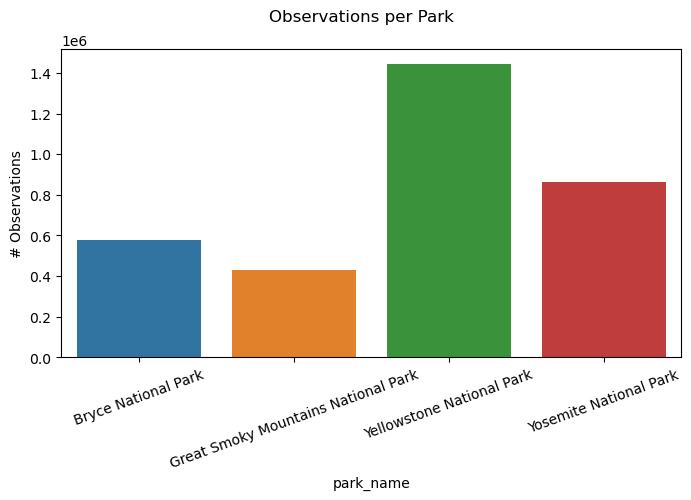

<Figure size 640x480 with 0 Axes>

In [9]:
# Number of Observations per Park in new Dataframe
park_df = obs_df.groupby('park_name').sum().reset_index()
park_df = park_df.drop(columns = ['scientific_name'])
print('DataFrame grouped by Park Name: \n')
print(park_df.head())

# Barplot
plt.figure(figsize=(8,4)).suptitle('Observations per Park')
sns.barplot(data=park_df, x='park_name', y='observations', hue='park_name')
plt.ylabel('# Observations')
plt.xticks(rotation=20)
plt.show()
plt.clf()


# Analysis

### 1. What is The Distribution of Conservation Statuses for All Species?

#### By Number of Observations
>- **'Species of Concern' is the most reported conservation category. There is an instance of each species type in this category as well. The next cell will dial in on the proportional rate of each species per category.**

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  Reptile  Vascular Plant
conservation_status                                                                           
Endangered                 1.0   4.0   3.0     7.0                NaN      NaN             1.0
In Recovery                NaN   3.0   NaN     1.0                NaN      NaN             NaN
Species of Concern         4.0  72.0   4.0    28.0                5.0      5.0            43.0
Threatened                 2.0   NaN   4.0     2.0                NaN      NaN             2.0 

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  Reptile  Vascular Plant
conservation_status                                                                           
Endangered                 1.0   4.0   3.0     7.0                0.0      0.0             1.0
In Recovery                0.0   3.0   0.0     1.0                0.0      0.0             0.0
Species of Concern         4.0  72.0   4.0    28

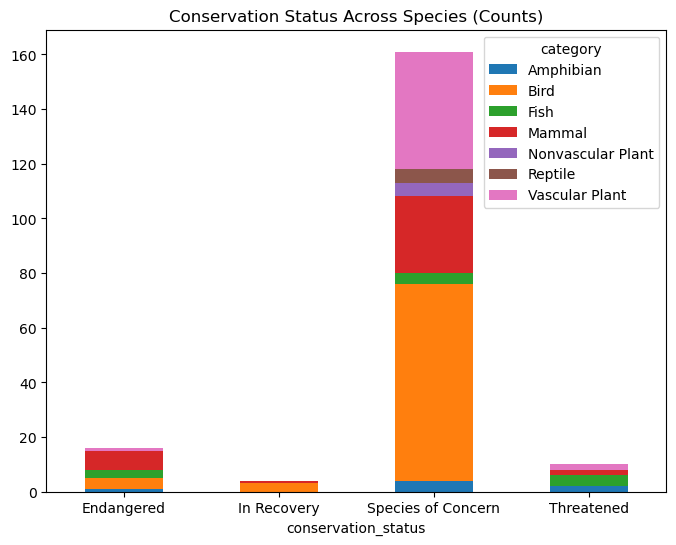

<Figure size 640x480 with 0 Axes>

In [10]:
# create new dataframe that eliminates the no intervention category
conservation_statusdf = si_df[si_df.conservation_status != "No Intervention"]\
    .groupby(["conservation_status", "category"])['scientific_name']\
    .count()\
    .unstack()

print(conservation_statusdf.head(), '\n')

# clean NaN values
conservation_statusdf = conservation_statusdf.fillna(0)
print(conservation_statusdf.head(), '\n')

# Stacked bar chart to see distribution of conservation status across all species
conservation_statusdf.plot(kind = 'bar', figsize=(8,6), stacked=True)
plt.title('Conservation Status Across Species (Counts)')
plt.xticks(rotation=0)
plt.show()
plt.clf()



#### Proportionally

>- **Species with the largest presence in conservation categories: Mammal, Bird, Amphibian, Fish.**

Proportions 

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  Reptile  Vascular Plant
conservation_status                                                                           
Endangered                 6.2  25.0  18.8    43.8                0.0      0.0             6.2
In Recovery                0.0  75.0   0.0    25.0                0.0      0.0             0.0
Species of Concern         2.5  44.7   2.5    17.4                3.1      3.1            26.7
Threatened                20.0   0.0  40.0    20.0                0.0      0.0            20.0


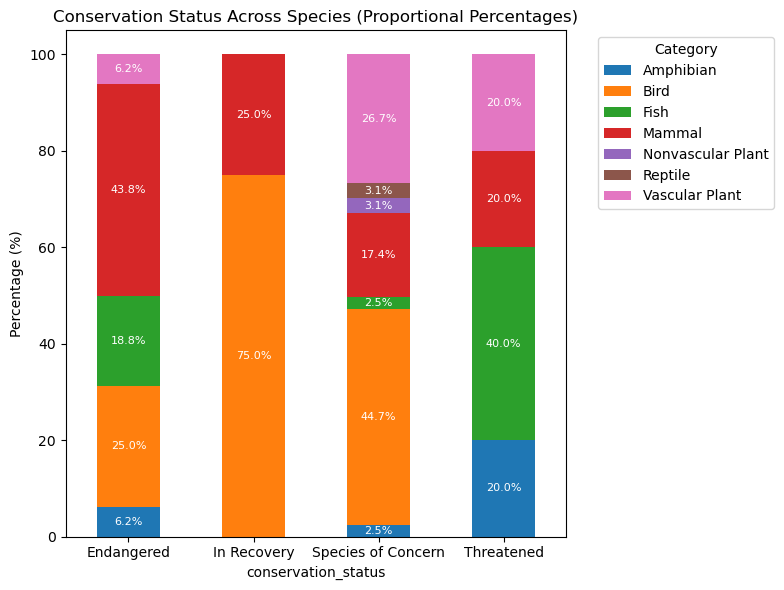

In [11]:
# create a df of proportions to show each species' percentage of the conservation status data
print(f'Proportions \n')
totals = conservation_statusdf.sum(axis=1)

proportionsdf = round(conservation_statusdf.div(totals, axis=0).mul(100, axis=0), 1)
# proportionsdf['total'] = proportionsdf.sum(axis=1)
print(proportionsdf)

# Create a bar plot with proportional values
ax = proportionsdf.plot(kind='bar', stacked=True, figsize=(8, 6))

for i, bar_group in enumerate(ax.containers):
    for bar in bar_group:
        if bar.get_height() > 0:  # Avoid showing labels for 0 heights
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # Center of the bar segment
                bar.get_y() + bar.get_height() / 2,  # Middle of the segment
                f"{bar.get_height():.1f}%",  # Format percentage
                ha='center', va='center', fontsize=8, color='white'
            )

plt.ylabel('Percentage (%)')
plt.title('Conservation Status Across Species (Proportional Percentages)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()


### 2. Are certain types of species more likely to be endangered?

#### Comparison by rate of protection

>- **Cleaned conservation status column within the species_info data frame in order to represent non-protected species.**

In [12]:
# cleaning si_df.conservation_status to fill NaN with No Intervention to better
# represent the population in plotting this column

si_df.conservation_status = si_df.conservation_status.fillna('No Intervention')
print(si_df.head())

  category                scientific_name                                                    common_names conservation_status
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole     No Intervention
1   Mammal                      Bos bison                                           American Bison, Bison     No Intervention
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle     No Intervention
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)     No Intervention
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk     No Intervention


>- **Create boolean is_protected column.**

In [13]:
si_df['is_protected'] = si_df['conservation_status'] != 'No Intervention'
print(si_df.head())

  category                scientific_name                                                    common_names conservation_status  is_protected
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole     No Intervention         False
1   Mammal                      Bos bison                                           American Bison, Bison     No Intervention         False
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle     No Intervention         False
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)     No Intervention         False
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk     No Intervention         False


>- **Create a boolean 'is_protected' Data Frame in order to show Intervention vs non-Intervention proportionally.**

In [14]:
is_protected_df = si_df.groupby(['category', 'is_protected'])\
                        .scientific_name.nunique()\
                        .reset_index()\
                        .pivot(columns='is_protected',
                                      index='category',
                                      values='scientific_name')\
                        .reset_index()
is_protected_df.columns = ['category', 'not_protected', 'protected']
print(f'is_protected_df by counts:\n{is_protected_df} \n')

# Create a new DataFrame with the calculated percentage
is_protected_df_percent = is_protected_df.assign(
    percentage_protected=is_protected_df['protected'] / 
    (is_protected_df['protected'] + is_protected_df['not_protected']) * 100
)

print(f'is_protected_df by percentage:\n{is_protected_df_percent} \n')

is_protected_df by counts:
            category  not_protected  protected
0          Amphibian             72          7
1               Bird            413         75
2               Fish            115         11
3             Mammal            146         30
4  Nonvascular Plant            328          5
5            Reptile             73          5
6     Vascular Plant           4216         46 

is_protected_df by percentage:
            category  not_protected  protected  percentage_protected
0          Amphibian             72          7              8.860759
1               Bird            413         75             15.368852
2               Fish            115         11              8.730159
3             Mammal            146         30             17.045455
4  Nonvascular Plant            328          5              1.501502
5            Reptile             73          5              6.410256
6     Vascular Plant           4216         46              1.079305 



#### Proportional Rate of Species Type in the Endangered Category

>- **Create a Data Frame for ONLY endangered species in order to derive the proportion of 'endangered species category' out of 'total endangered species'.**

In [15]:
# making a df for endangered species
endangered_df = si_df[si_df['conservation_status'] == 'Endangered']
# print(endangered_df, '\n')

# create df for endangered species per category
per_cat_df = endangered_df['category'].value_counts().reset_index()
print(f'# of Endangered Species per Category \n{per_cat_df.head()} \n')

total = per_cat_df['count'].sum()
per_cat_df['percentage'] = round(per_cat_df['count'] / total, 2)*100
print(f'Percentage of Endangered Species per Category \n{per_cat_df}')

# of Endangered Species per Category 
         category  count
0          Mammal      7
1            Bird      4
2            Fish      3
3  Vascular Plant      1
4       Amphibian      1 

Percentage of Endangered Species per Category 
         category  count  percentage
0          Mammal      7        44.0
1            Bird      4        25.0
2            Fish      3        19.0
3  Vascular Plant      1         6.0
4       Amphibian      1         6.0


>- **Visualization**

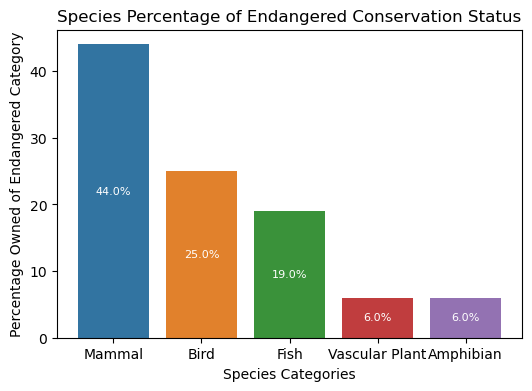

<Figure size 640x480 with 0 Axes>

In [16]:
# Bar plot of endangered species per category
plt.figure(figsize=(6,4))
ax = sns.barplot(data=per_cat_df, x='category', y='percentage', hue='category')
ax.plot(type='bar', hue='category')
plt.xlabel('Species Categories')
plt.ylabel('Percentage Owned of Endangered Category')

for i, bar_group in enumerate(ax.containers):
    for bar in bar_group:
        if bar.get_height() > 0:  # Avoid showing labels for 0 heights
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # Center of the bar segment
                bar.get_y() + bar.get_height() / 2,  # Middle of the segment
                f"{bar.get_height():.1f}%",  # Format percentage
                ha='center', va='center', fontsize=8, color='white'
            )
plt.title('Species Percentage of Endangered Conservation Status')            
plt.xticks(rotation=0)
plt.show()
plt.clf()



### 3. Do classes differ significantly across specific conservation statuses?

>- **Mammals vs Birds**

>- Implement a Chi-Square test to compare species categories. This will evaluate the significance of the difference in the distribution of their conservation statuses. 

~ Contingency Table Format

||Endangered|In Recovery|No Intervention|Species of Concern|Threatened|
|-|-|-|-|-|-|
|Mammal|?|?|?|?|?
|Bird|?|?|?|?|?

In [17]:
# create a data frame to aggregate conservation_status per species category
status_byspecies_df = si_df.groupby(['category', 'conservation_status']).size().unstack(fill_value=0)

print(f'~status_byspecies_df~ \n{status_byspecies_df}', '\n')

#create contingency table
print('~Mammal vs Bird Contingency Table~')
mammal_bird_contingency = status_byspecies_df.loc[['Mammal', 'Bird']]
print(mammal_bird_contingency)

~status_byspecies_df~ 
conservation_status  Endangered  In Recovery  No Intervention  Species of Concern  Threatened
category                                                                                     
Amphibian                     1            0               73                   4           2
Bird                          4            3              442                  72           0
Fish                          3            0              116                   4           4
Mammal                        7            1              176                  28           2
Nonvascular Plant             0            0              328                   5           0
Reptile                       0            0               74                   5           0
Vascular Plant                1            0             4424                  43           2 

~Mammal vs Bird Contingency Table~
conservation_status  Endangered  In Recovery  No Intervention  Species of Concern  Threatened


>- **Run Chi-Square Test and take p-value results to establish level of significance.**
>- - **The returned pval of 0.0221 tells us there is a significant statistical difference between the spread of conservation statuses of Mammals and Birds.**

In [18]:
chi2_mammal_bird, pval_mammal_bird, dof_mammal_bird, expected_vals_mammal_bird = chi2_contingency(mammal_bird_contingency)
# print(chi2_mammal_bird)
# print(expected_vals_mammal_bird)
print(f'Mammal vs Bird pval (less than .05 = statistical significant difference): {pval_mammal_bird}')


Mammal vs Bird pval (less than .05 = statistical significant difference): 0.022085036273887457


**Over/Under representation of species in conservation status groups based on standardized residuals.** 
- **Values of ≥ or ≤ ±2 means an over/under representation has occured compared to the expected values of these species in these conservation categories(produced by the Chi-Square function). These occurences happen in (Mammal, Endangered) and (Mammal, Threatened). Over/under representations compared to expected values can create larger chi2 contributions, *forcing* our observed differences to be statistically significant.**

In [19]:
# create a standardized residuals table
index = ['Mammal', 'Bird']
observed_vals_mammal_bird = mammal_bird_contingency.values
std_residuals = (observed_vals_mammal_bird - expected_vals_mammal_bird) / np.sqrt(expected_vals_mammal_bird)

std_residualsdf = pd.DataFrame(std_residuals, index=index, columns=mammal_bird_contingency.columns)
std_residualsdf


conservation_status,Endangered,In Recovery,No Intervention,Species of Concern,Threatened
Mammal,2.121841,-0.152547,-0.293328,-0.206758,1.857814
Bird,-1.359881,0.097767,0.187993,0.132511,-1.190667


>- **Mammal vs Bird Visualization**

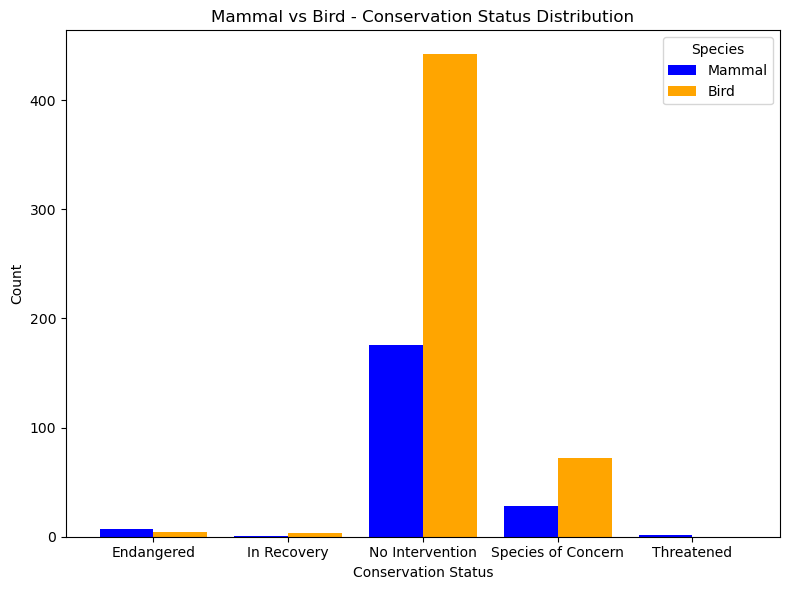

In [20]:
mammal_bird_contingency.T.plot(kind='bar', figsize=(8, 6), width=0.8, color=['blue', 'orange'])
plt.title('Mammal vs Bird - Conservation Status Distribution')
plt.ylabel('Count')
plt.xlabel('Conservation Status')
plt.xticks(rotation=0)
plt.legend(title="Species")
plt.tight_layout()
plt.show()

#### Conservation Status: Mammals vs Reptiles
##### Contingency Table

||Endangered|In Recovery|No Intervention|Species of Concern|Threatened|
|-|-|-|-|-|-|
|Mammal|?|?|?|?|?
|Reptile|?|?|?|?|?

In [21]:
#create contingency tables
print('~Mammal vs Reptile Contingency Table~')
mammal_reptile_contingency = status_byspecies_df.loc[['Mammal', 'Reptile']]
print(mammal_reptile_contingency)

~Mammal vs Reptile Contingency Table~
conservation_status  Endangered  In Recovery  No Intervention  Species of Concern  Threatened
category                                                                                     
Mammal                        7            1              176                  28           2
Reptile                       0            0               74                   5           0


**Chi-Square Test**
- **The returned value of 0.14059 tell us that there is no significant difference between Mammals and Reptiles.**

In [22]:
chi2_mammal_reptile, pval_mammal_reptile, dof, expected_vals_mam_rep = chi2_contingency(mammal_reptile_contingency)
print(f'Mammal vs Reptile pval (less than .05 = significant statistical difference): {pval_mammal_reptile}')

Mammal vs Reptile pval (less than .05 = significant statistical difference): 0.14059188116790175


>- **Standardized Residuals**

In [23]:
observed_vals_mam_rep = mammal_reptile_contingency.values
std_residuals_mam_rep = (observed_vals_mam_rep - expected_vals_mam_rep) / np.sqrt(expected_vals_mam_rep)

std_residuals_mam_repdf = pd.DataFrame(std_residuals_mam_rep, index=['Mammal', 'Reptile'], columns=mammal_reptile_contingency.columns)
print('Standardized Residuals Table:')
std_residuals_mam_repdf

Standardized Residuals Table:


conservation_status,Endangered,In Recovery,No Intervention,Species of Concern,Threatened
Mammal,0.834710,0.315491,-0.487974,0.793905,0.446171
Reptile,-1.373817,-0.519254,0.803137,-1.306658,-0.734336


Visualization

- We can see here that there is a visually significant difference between Mammals and Reptiles when it comes to conservation status but because of the coniditions of this contingency(designated .05 pval threshold and the low number of records for either category in statuses "endangered", "in recovery", or 'threatened'), we cannot be confident that there is a significant difference between Mammals and Reptiles. 

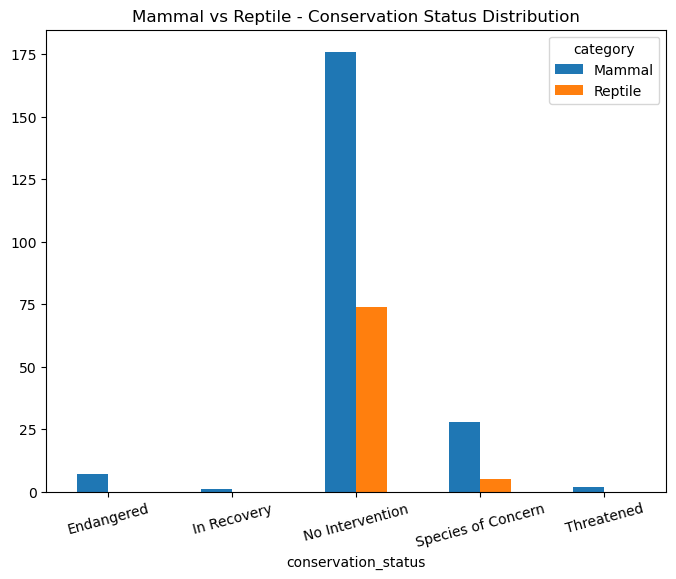

<Figure size 640x480 with 0 Axes>

In [24]:
mammal_reptile_contingency.T.plot(kind='bar', figsize=(8, 6))
plt.title('Mammal vs Reptile - Conservation Status Distribution')
plt.xticks(rotation=15)
plt.show()
plt.clf()

### 4. Do species differ significantly in the overall likelihood of being protected?

#### Protection Status: Mammals vs Birds

##### Contingency Table and Chi-Square p-value
||not protected|protected|
|-|-|-|
|Mammal|?|?|
|Bird|?|?|

In [25]:
protection_mammal_bird_contingency = is_protected_df.set_index('category').loc[['Mammal', 'Bird']]
print(protection_mammal_bird_contingency)

chi2_mammal_bird_protection, pval_mammal_bird_protection, dof, expected_vals_mammal_bird_protection = chi2_contingency(protection_mammal_bird_contingency)
print(f'pval of Protection Status - Mammal vs Bird: {pval_mammal_bird_protection}')

          not_protected  protected
category                          
Mammal              146         30
Bird                413         75
pval of Protection Status - Mammal vs Bird: 0.6875948096661336


#### Standardized Residuals to show over/under representation of species in conservation status groups.
>- **Our residual values for each cell in the table are close to 0. This indicates that the observed values fall very close to the expected values of Mammal and Bird in both protection statuses. Therefore, we can be confident when we say there is no significant difference between Mammals and Birds in these categories and that they have similar distributions.**

In [26]:
index = ['Mammal', 'Bird']
observed_vals_mammal_bird_protection = protection_mammal_bird_contingency.values
std_residuals_mam_bird_protection = (observed_vals_mammal_bird_protection - expected_vals_mammal_bird_protection) / np.sqrt(expected_vals_mammal_bird_protection)

std_residualsdf = pd.DataFrame(std_residuals_mam_bird_protection, index=index, columns=protection_mammal_bird_contingency.columns)
print('Standardized Residuals Table:')
std_residualsdf

Standardized Residuals Table:


,not_protected,protected
Mammal,-0.178162,0.411081
Bird,0.106995,-0.246873


##### **Visualization**

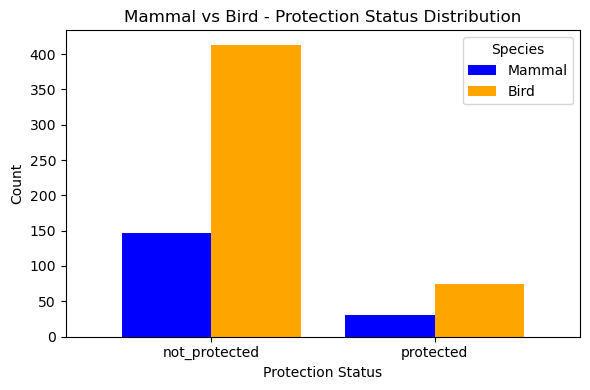

In [27]:
protection_mammal_bird_contingency.T.plot(kind='bar', figsize=(6, 4), width=0.8, color=['blue', 'orange'])
plt.title('Mammal vs Bird - Protection Status Distribution')
plt.ylabel('Count')
plt.xlabel('Protection Status')
plt.xticks(rotation=0)
plt.legend(title="Species")
plt.tight_layout()
plt.show()

#### Protection Status: Mammals vs Reptiles

##### Contingency Table and Chi-Square Stats

||not protected|protected|
|-|-|-|
|Mammal|?|?|
|Reptile|?|?|

In [28]:
prot_mam_rep_contingency = is_protected_df.set_index('category').loc[['Mammal', 'Reptile']]
print(prot_mam_rep_contingency)

chi2_mam_rep_protection, pval_mam_rep_prot, dof, expected_vals_mam_rep_prot = chi2_contingency(prot_mam_rep_contingency)
print(f'pval of Protection Status - Mammal vs Reptile: {pval_mam_rep_prot}')

          not_protected  protected
category                          
Mammal              146         30
Reptile              73          5
pval of Protection Status - Mammal vs Reptile: 0.038355590229699


##### Standardized Residuals

In [29]:
observed_vals_mam_rep_prot = prot_mam_rep_contingency.values
std_residuals_mam_rep_prot = (observed_vals_mam_rep_prot - expected_vals_mam_rep_prot) / np.sqrt(expected_vals_mam_rep_prot)

std_residuals_mam_rep_protdf = pd.DataFrame(std_residuals_mam_rep_prot, index=['Mammal', 'Reptile'], columns=prot_mam_rep_contingency.columns)
print('Standardized Residuals Table:')
std_residuals_mam_rep_protdf

Standardized Residuals Table:


,not_protected,protected
Mammal,-0.466614,1.167201
Reptile,0.700917,-1.753294


##### Visualization

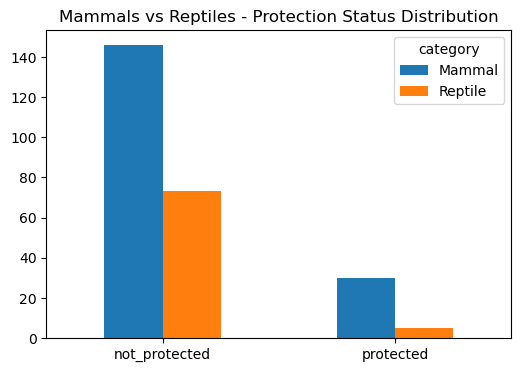

<Figure size 640x480 with 0 Axes>

In [30]:
prot_mam_rep_contingency.T.plot(kind='bar', figsize=(6,4))
plt.title('Mammals vs Reptiles - Protection Status Distribution')
plt.xticks(rotation=0)
plt.show()
plt.clf()

### 5. Which species was spotted the most at each park and what is their distribution amongst parks?

 - **Clean species_info.csv for commas and parenthesis.**

In [31]:
from itertools import chain
import string

print(si_df.head())

def remove_punctuations(text):
    for punctuation in string.punctuation:
        text=text.replace(punctuation, '')
    return text

common_names = si_df.common_names.apply(remove_punctuations).str.split().to_list()
common_names[:6]



  category                scientific_name                                                    common_names conservation_status  is_protected
0   Mammal  Clethrionomys gapperi gapperi                                        Gapper's Red-Backed Vole     No Intervention         False
1   Mammal                      Bos bison                                           American Bison, Bison     No Intervention         False
2   Mammal                     Bos taurus  Aurochs, Aurochs, Domestic Cattle (Feral), Domesticated Cattle     No Intervention         False
3   Mammal                     Ovis aries               Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)     No Intervention         False
4   Mammal                 Cervus elaphus                                                   Wapiti Or Elk     No Intervention         False


[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison', 'Bison'],
 ['Aurochs',
  'Aurochs',
  'Domestic',
  'Cattle',
  'Feral',
  'Domesticated',
  'Cattle'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Sheep', 'Sheep', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

>- **Remove duplicates from list to count only one instance per row.**

In [32]:
cleaned_commonNames = []

for item in common_names:
    item = list(dict.fromkeys(item))
    cleaned_commonNames.append(item)

cleaned_commonNames[:6]

[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison'],
 ['Aurochs', 'Domestic', 'Cattle', 'Feral', 'Domesticated'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

>- **Reduce down to one list for easier analysis.**

In [33]:
commonNames_list = list(chain.from_iterable(i if isinstance(i, list) else [i] for i in cleaned_commonNames))
commonNames_list[:20]

['Gappers',
 'RedBacked',
 'Vole',
 'American',
 'Bison',
 'Aurochs',
 'Domestic',
 'Cattle',
 'Feral',
 'Domesticated',
 'Domestic',
 'Sheep',
 'Mouflon',
 'Red',
 'Feral',
 'Wapiti',
 'Or',
 'Elk',
 'WhiteTailed',
 'Deer']

- **Analyze for the most occurences.**

- **Moss was the most occuring common name in the data frame.**

In [34]:
counter = []
for name in commonNames_list:
    count = commonNames_list.count(name)
    counter.append((name, count))

# counter[:10]

pd.DataFrame(set(counter), columns=['Name', 'Count']).sort_values("Count", ascending = False).head(10)


,Name,Count
2988,Moss,285
336,Sedge,227
2959,Common,185
450,Mountain,148
528,Grass,134
4061,Western,114
207,American,106
4665,Northern,100
4152,White,95
4742,Wild,88


- **Merging data frames in order to link observations(obs_df) to common_names(si_df) by their scientific_names(shared between both data frames).**

In [35]:
# print(si_df[si_df['common_names'].str.contains(r'\bWolf\b', regex = True)])

merged_df = obs_df.merge(si_df[si_df.common_names.str.contains(r'\bMoss\b')])
print(merged_df[merged_df.common_names.str.contains(r'\bMoss\b', regex=True)])

                     scientific_name                            park_name  observations           category                common_names conservation_status  is_protected
0         Diphyscium cumberlandianum            Yellowstone National Park           250  Nonvascular Plant  Cumberland Diphyscium Moss     No Intervention         False
1                  Fabronia ciliaris  Great Smoky Mountains National Park            72  Nonvascular Plant               Fabronia Moss     No Intervention         False
2          Ptilium crista-castrensis                  Bryce National Park           109  Nonvascular Plant          Knights Plume Moss     No Intervention         False
3     Didymodon fallax var. reflexus            Yellowstone National Park           208  Nonvascular Plant              Didymodon Moss     No Intervention         False
4             Orthotrichum stellatum  Great Smoky Mountains National Park            71  Nonvascular Plant  Stellate Orthotrichum Moss     No Intervention 

- **Grouping**

In [36]:
grouped = merged_df.groupby(['scientific_name', 'common_names', 'category', 'park_name', 'conservation_status', 'is_protected'])['observations'].sum().reset_index()
grouped

,scientific_name,common_names,category,park_name,conservation_status,is_protected,observations
0,Abietinella abietina,Abietinella Moss,Nonvascular Plant,Bryce National Park,No Intervention,False,101
1,Abietinella abietina,Abietinella Moss,Nonvascular Plant,Great Smoky Mountains National Park,No Intervention,False,65
2,Abietinella abietina,Abietinella Moss,Nonvascular Plant,Yellowstone National Park,No Intervention,False,243
3,Abietinella abietina,Abietinella Moss,Nonvascular Plant,Yosemite National Park,No Intervention,False,183
4,Amblystegium serpens,Amblystegium Moss,Nonvascular Plant,Bryce National Park,No Intervention,False,112
...,...,...,...,...,...,...,...
1159,Zygodon viridissimus,Zygodon Moss,Nonvascular Plant,Yosemite National Park,No Intervention,False,159
1160,Zygodon viridissimus var. rupestris,Zygodon Moss,Nonvascular Plant,Bryce National Park,No Intervention,False,102
1161,Zygodon viridissimus var. rupestris,Zygodon Moss,Nonvascular Plant,Great Smoky Mountains National Park,No Intervention,False,102
1162,Zygodon viridissimus var. rupestris,Zygodon Moss,Nonvascular Plant,Yellowstone National Park,No Intervention,False,237


- **Filter by common_names containing Moss.**

In [37]:
filtered = grouped[grouped['common_names'].str.contains(r'\bMoss\b', regex=True)]
print(filtered)

                          scientific_name       common_names           category                            park_name conservation_status  is_protected  observations
0                    Abietinella abietina   Abietinella Moss  Nonvascular Plant                  Bryce National Park     No Intervention         False           101
1                    Abietinella abietina   Abietinella Moss  Nonvascular Plant  Great Smoky Mountains National Park     No Intervention         False            65
2                    Abietinella abietina   Abietinella Moss  Nonvascular Plant            Yellowstone National Park     No Intervention         False           243
3                    Abietinella abietina   Abietinella Moss  Nonvascular Plant               Yosemite National Park     No Intervention         False           183
4                    Amblystegium serpens  Amblystegium Moss  Nonvascular Plant                  Bryce National Park     No Intervention         False           112
...       

- **number of observations of Moss per park**

In [41]:
moss_by_park = filtered.groupby(['park_name', 'is_protected']).observations.sum().reset_index()
(moss_by_park)


,park_name,is_protected,observations
0,Bryce National Park,False,28690
1,Bryce National Park,True,270
2,Great Smoky Mountains National Park,False,21464
3,Great Smoky Mountains National Park,True,174
4,Yellowstone National Park,False,72104
5,Yellowstone National Park,True,679
6,Yosemite National Park,False,43248
7,Yosemite National Park,True,414


- **Visualization**

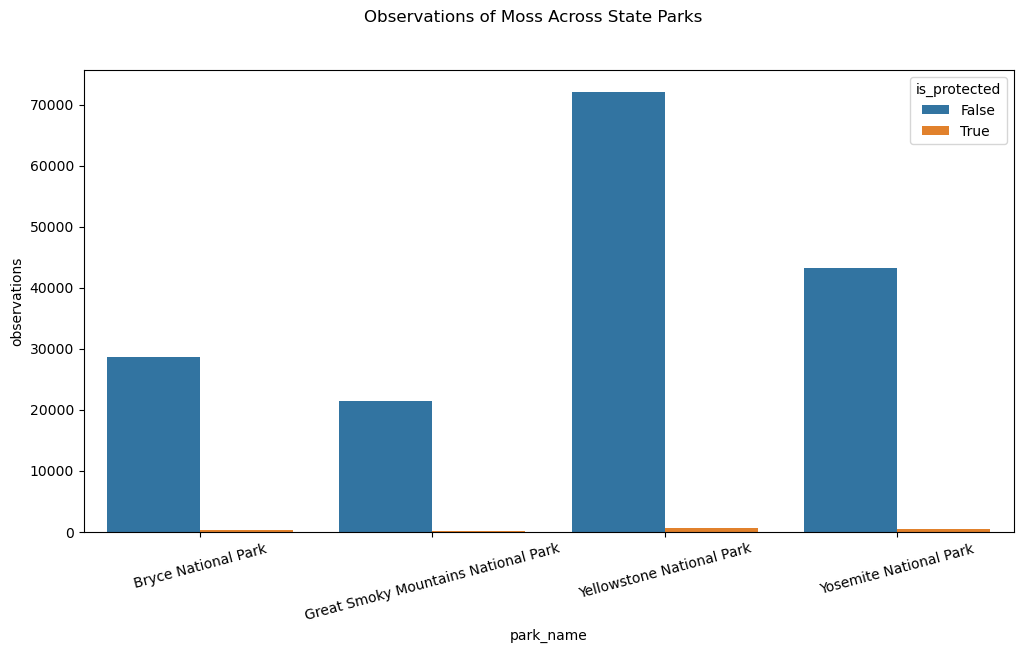

<Figure size 640x480 with 0 Axes>

In [39]:
plt.figure(figsize=(12,6)).suptitle('Observations of Moss Across State Parks')
sns.barplot(x=moss_by_park.park_name, y= moss_by_park.observations, hue=moss_by_park.is_protected)
plt.xticks(rotation=15)
plt.show()
plt.clf()

# Conclusions
1. What is the distribution of conservation_status for all species?
    - Most species are not in conservation and are now reflecting a "No Intervention" status in the DataFrames.

2. Are certain Classes of species more likely to be endangered?   
    - Mammals are more likely to be endangered across these four state parks. This answer was derived using the proportional rate of each species class in the edangered category and the proportional rate of overall protection per class.

3. Do species differ significantly across specific conservation statuses?
    - Mammals and Birds initially showed statistically significant differences across each conservation status. Mammals and Reptiles did not calculate to be significantly different. This would seem to be contradictory given that Birds were represented more in each status of conservation compared to Reptiles. The standardized residuals then showed that Mammals were over represented in the 'Endangered' and 'Threatened' categories within the Chi-Square test. This is why we recieved an inflated p-value in the Mammals vs Birds test. Smaller sample sizes can affect these calculations, which is most likely what led us to the 'insignificant' result of the Mammals vs Reptiles test. This was the result of the way the data was spread across all conservation statuses and the way the Chi-Square test is calculated.

4. Do classes of species differ significantly in the overall likelihood of being protected?
    - Conservation statuses were transformed into protected vs not-protected categories. The Chi-Square tests ran on this table showed no significant difference between the instance of protection for Mammals and Birds. It **DID** show a significant difference between Birds and Reptiles, which was less surprising because of the Reptiles lack of representation in the 'threatened', 'endangered', and 'in_recovery' statuses.

5. Which class was spotted the most at each park and what is their distribution amongst parks?
    - Moss was the most observed throughout the whole dataset. It was mostly recorded at Yellow Stone National Park.


# Futher Research
1. The area of each National Park to determine if the size of the parks skewed some results. (Most observations coming from Yellow Stone)
2. Researching over a longer time frame in order to obtain larger sample sizes. Also, to track sightings and shifts in conservation stauses over time.